In [1]:
import pandas as pd
import numpy as np
import logging
import math

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 150)

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Data

In [ ]:
df = pd.read_feather('df_features_for_model')

In [ ]:
df_emotions = pd.read_feather('df_feature_emotions').rename({
    'index': 'path',
    '0': 'arousal',
    '1': 'dominance',
    '2': 'valence'
}, axis=1)

In [6]:
df = pd.merge(
    df,
    df_emotions
)

## EDA for emotions

In [7]:
# очень похожие значения, так как в треках почти нет слов
df.groupby('major_mood_class', as_index=False)[['arousal', 'dominance', 'valence']].describe().T

0               1          2         3  \
major_mood_class            calm  deep_emotional  energetic  positive   
arousal          count    4326.0           793.0     2452.0    5126.0   
                 mean   -0.02481       -0.024456  -0.024437 -0.023505   
                 std    0.013534        0.012115   0.012214  0.011554   
                 min   -0.087928       -0.067595  -0.082957 -0.080978   
                 25%   -0.032596        -0.03214  -0.031619 -0.030776   
                 50%   -0.024465       -0.024044  -0.023751 -0.023904   
                 75%   -0.016339       -0.016257  -0.016792 -0.016255   
                 max    0.024255        0.009253   0.025175  0.036183   
dominance        count    4326.0           793.0     2452.0    5126.0   
                 mean   0.012619        0.012128   0.007654  0.006581   
                 std    0.011105        0.010618   0.010337  0.010311   
                 min   -0.023857       -0.028554   -0.02569 -0.031678   
                 25%    0.004704        0.004718   0.000323 -0.000301   
                 50%     0.01292        0.012005   0.007438  0.006213   
                 75%    0.020819         0.02041   0.014601  0.013407   
                 max    0.043376        0.039974   0.038421  0.038001   
valence          count    4326.0           793.0     2452.0    5126.0   
                 mean   0.009938        0.007725   0.008205  0.008508   
                 std    0.010279         0.01069   0.010149  0.010438   
                 min   -0.035342       -0.030562  -0.033916 -0.052132   
                 25%    0.003037        0.000996   0.001514  0.001418   
                 50%    0.009881        0.007156    0.00808  0.008496   
                 75%    0.016984        0.014673   0.015166  0.015587   
                 max    0.042974        0.039375   0.040996  0.050792   

                               4         5  
major_mood_class        romantic  sad_dark  
arousal          count     919.0    1987.0  
                 mean  -0.022947   -0.0261  
                 std    0.012166  0.015026  
                 min   -0.073631 -0.092591  
                 25%   -0.030235 -0.034107  
                 50%   -0.023182 -0.025027  
                 75%    -0.01514 -0.017326  
                 max    0.030499  0.031223  
dominance        count     919.0    1987.0  
                 mean   0.009609  0.012474  
                 std    0.009895  0.011445  
                 min   -0.036095 -0.027007  
                 25%    0.002719  0.004438  
                 50%    0.009475  0.012975  
                 75%    0.016393  0.020689  
                 max    0.040188  0.043346  
valence          count     919.0    1987.0  
                 mean   0.011069  0.009192  
                 std    0.010005  0.010728  
                 min   -0.033403 -0.029226  
                 25%    0.004478  0.002047  
                 50%    0.011334  0.009159  
                 75%    0.018211  0.016245  
                 max    0.049149  0.049327

In [8]:
mood_colors_soft = {
    'is_positive': '#5DBE7E',       
    'is_sad_dark': '#6C8EB0',        
    'is_energetic': '#D96C6C',      
    'is_deep_emotional': '#B19CD9', 
    'is_calm': '#87CEEB',         
    'is_romantic': '#F4AFC8'
}

def get_hist_of_audio_features(df_audio, group_columns, feature_list, cols_per_row=4):

    n_features = len(feature_list)
    n_rows = math.ceil(n_features / cols_per_row)

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5 * cols_per_row, 4 * n_rows))
    axes = axes.flatten()

    for i, feature in enumerate(feature_list):
        ax = axes[i]
        for mood in group_columns:
            data = df_audio[df_audio[mood] == 1][feature]
            sns.kdeplot(data=data, label=mood, fill=True, alpha=0.2, color=mood_colors_soft[mood], ax=ax)

        ax.set_title(f'{feature}')
        ax.set_xlabel('')
        ax.set_ylabel('Плотность')
        ax.legend(fontsize=8)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [9]:
mood_flg_columns = [x for x in df.columns if x.startswith('is_')]

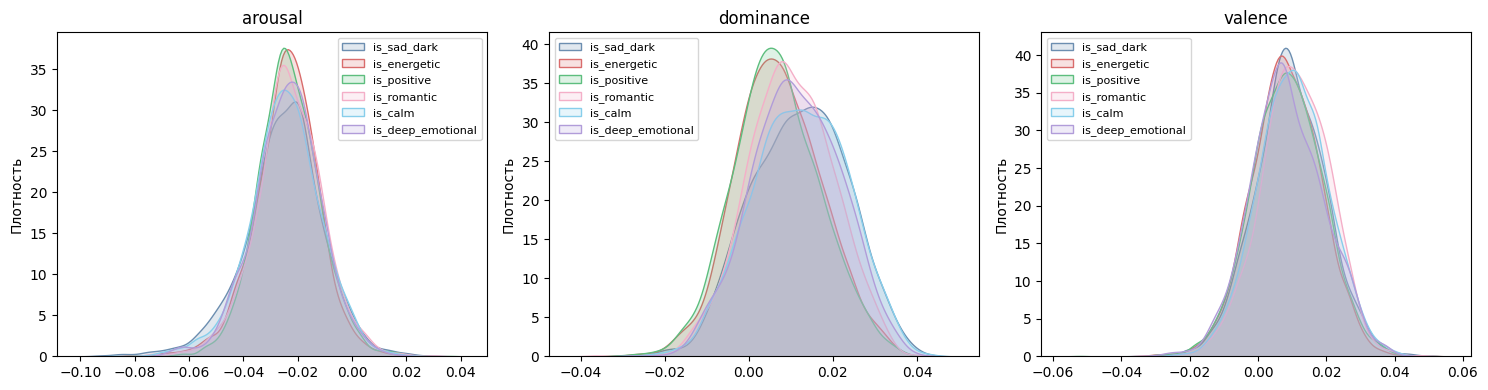

In [10]:
get_hist_of_audio_features(df, mood_flg_columns, ['arousal', 'dominance', 'valence'], cols_per_row=3)

### columns for model

- Для начала возьмем аудио-признаки, длительность трека и год релиза
- Будем предсказывать главное настроение трека

In [11]:
def data_preprocessing(df_):

    df = df_.copy()

    df['release_date'] = pd.to_datetime(df['release_date'])
    df['release_year'] = df['release_date'].dt.year

    df['genre_cnt'] = df['genre'].apply(lambda x: len(x))
    df['genre'] = df['genre'].apply(lambda x: ', '.join(sorted(x)))

    df['instrument_cnt'] = df['instrument'].apply(lambda x: len(x))
    df['instrument'] = df['instrument'].apply(lambda x: ', '.join(sorted(x)))

    df.drop([
        'track_id',
        'artist_id',
        'album_id',
        'path',
        'mood/theme',
        'track_name',
        'release_date',
        'url',
        'mood_class',
        'situation_class',
        'for_summer',
        'for_children',
        'for_holiday',
        'for_sport',
        'for_christmas',
        'for_travel',
        'for_party',
        'is_sad_dark', 
        'is_energetic', 
        'is_positive', 
        'is_romantic', 
        'is_calm', 
        'is_deep_emotional'
    ], axis=1, inplace=True)

    return df

In [12]:
df_prep = data_preprocessing(df)

In [13]:
df_prep.columns

Index(['duration', 'genre', 'instrument', 'artist_name', 'album_name',
       '0_Absolute energy', '0_Autocorrelation', '0_Centroid',
       '0_ECDF Percentile Count_0', '0_ECDF Percentile_0', '0_Entropy',
       '0_Histogram mode', '0_Interquartile range', '0_Kurtosis', '0_Max',
       '0_Mean absolute diff', '0_Mean diff', '0_Median absolute deviation',
       '0_Median absolute diff', '0_Median diff', '0_Min',
       '0_Negative turning points', '0_Neighbourhood peaks',
       '0_Signal distance', '0_Skewness', '0_Slope', '0_Zero crossing rate',
       'spectral_centroid_mean', 'zcr_mean', 'rms_mean', 'bandwidth_mean',
       'flatness_mean', 'spectral_centroid_std', 'rolloff_std', 'zcr_std',
       'rms_std', 'bandwidth_std', 'flatness_std', 'tempo', 'mfcc_mean_1',
       'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4', 'mfcc_mean_5',
       'mfcc_mean_6', 'mfcc_mean_7', 'mfcc_mean_8', 'mfcc_mean_9',
       'mfcc_mean_10', 'mfcc_mean_11', 'mfcc_mean_12', 'mfcc_mean_13',
       'mfcc_st

In [14]:
only_audio_full = [
    '0_Autocorrelation', '0_Centroid', '0_ECDF Percentile Count_0',
    '0_ECDF Percentile_0', '0_Entropy', '0_Histogram mode',
    '0_Interquartile range', '0_Kurtosis', '0_Max', '0_Mean absolute diff',
    '0_Mean diff', '0_Median absolute deviation', '0_Median absolute diff',
    '0_Median diff', '0_Min', '0_Negative turning points',
    '0_Neighbourhood peaks', '0_Signal distance', '0_Skewness', '0_Slope',
    '0_Zero crossing rate', 'spectral_centroid_mean', 'zcr_mean',
    'rms_mean', 'bandwidth_mean', 'flatness_mean', 'spectral_centroid_std',
    'rolloff_std', 'zcr_std', 'rms_std', 'bandwidth_std', 'flatness_std',
    'tempo', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4',
    'mfcc_mean_5', 'mfcc_mean_6', 'mfcc_mean_7', 'mfcc_mean_8',
    'mfcc_mean_9', 'mfcc_mean_10', 'mfcc_mean_11', 'mfcc_mean_12',
    'mfcc_mean_13', 'mfcc_std_1', 'mfcc_std_2', 'mfcc_std_3', 'mfcc_std_4',
    'mfcc_std_5', 'mfcc_std_6', 'mfcc_std_7', 'mfcc_std_8', 'mfcc_std_9',
    'mfcc_std_10', 'mfcc_std_11', 'mfcc_std_12', 'mfcc_std_13',
    'chroma_mean_1', 'chroma_mean_2', 'chroma_mean_3', 'chroma_mean_4',
    'chroma_mean_5', 'chroma_mean_6', 'chroma_mean_7', 'chroma_mean_8',
    'chroma_mean_9', 'chroma_mean_10', 'chroma_mean_11', 'chroma_mean_12',
    'chroma_std_1', 'chroma_std_2', 'chroma_std_3', 'chroma_std_4',
    'chroma_std_5', 'chroma_std_6', 'chroma_std_7', 'chroma_std_8',
    'chroma_std_9', 'chroma_std_10', 'chroma_std_11', 'chroma_std_12'
]

only_librosa = [
    'spectral_centroid_mean', 'zcr_mean',
    'rms_mean', 'bandwidth_mean', 'flatness_mean', 'spectral_centroid_std',
    'rolloff_std', 'zcr_std', 'rms_std', 'bandwidth_std', 'flatness_std',
    'tempo', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4',
    'mfcc_mean_5', 'mfcc_mean_6', 'mfcc_mean_7', 'mfcc_mean_8',
    'mfcc_mean_9', 'mfcc_mean_10', 'mfcc_mean_11', 'mfcc_mean_12',
    'mfcc_mean_13', 'mfcc_std_1', 'mfcc_std_2', 'mfcc_std_3', 'mfcc_std_4',
    'mfcc_std_5', 'mfcc_std_6', 'mfcc_std_7', 'mfcc_std_8', 'mfcc_std_9',
    'mfcc_std_10', 'mfcc_std_11', 'mfcc_std_12', 'mfcc_std_13',
    'chroma_mean_1', 'chroma_mean_2', 'chroma_mean_3', 'chroma_mean_4',
    'chroma_mean_5', 'chroma_mean_6', 'chroma_mean_7', 'chroma_mean_8',
    'chroma_mean_9', 'chroma_mean_10', 'chroma_mean_11', 'chroma_mean_12',
    'chroma_std_1', 'chroma_std_2', 'chroma_std_3', 'chroma_std_4',
    'chroma_std_5', 'chroma_std_6', 'chroma_std_7', 'chroma_std_8',
    'chroma_std_9', 'chroma_std_10', 'chroma_std_11', 'chroma_std_12'
]

# визуально маленькая изменчивость и без std
only_audio_part = [
    '0_Autocorrelation', '0_Centroid',
    '0_ECDF Percentile_0', '0_Histogram mode',
    '0_Interquartile range', '0_Kurtosis', '0_Max', '0_Mean absolute diff',
    '0_Mean diff', '0_Median absolute deviation', '0_Median absolute diff',
    '0_Min', '0_Negative turning points',
    '0_Neighbourhood peaks', '0_Signal distance', '0_Skewness', '0_Slope',
    'spectral_centroid_mean', 'zcr_mean',
    'rms_mean', 'bandwidth_mean', 'flatness_mean', 'spectral_centroid_std',
    'rolloff_std', 'zcr_std', 'rms_std', 'bandwidth_std', 'flatness_std',
    'tempo', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4',
    'mfcc_mean_5', 'mfcc_mean_6', 'mfcc_mean_7', 'mfcc_mean_8',
    'mfcc_mean_9', 'mfcc_mean_10', 'mfcc_mean_11', 'mfcc_mean_12',
    'mfcc_mean_13', 'chroma_mean_1', 'chroma_mean_2', 'chroma_mean_3', 'chroma_mean_4',
    'chroma_mean_5', 'chroma_mean_6', 'chroma_mean_7', 'chroma_mean_8',
    'chroma_mean_9', 'chroma_mean_10', 'chroma_mean_11', 'chroma_mean_12',
]

meta_full = [
    'duration', 'genre', 'instrument', 'artist_name', 'album_name',
    'release_year', 'genre_cnt', 'instrument_cnt'
]

meta_num = [
    'duration','release_year', 'genre_cnt', 'instrument_cnt'
]

emotion_features = ['arousal', 'dominance', 'valence']

## Train_test split

In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold

1. Классы не сбалансированы: romantic и deep_emotional встречаются в 6 раз реже, чем самый частотный класс
2. К-fold берем стратифицированный, так как классы не сбалансированы

In [16]:
X, y = df_prep.drop('major_mood_class', axis=1).loc[:, only_audio_full+emotion_features], df['major_mood_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
y.value_counts(normalize=True)

major_mood_class
positive          0.328527
calm              0.277254
energetic         0.157149
sad_dark          0.127347
romantic          0.058899
deep_emotional    0.050824
Name: proportion, dtype: float64

In [18]:
y_train.value_counts(normalize=True)

major_mood_class
positive          0.336019
calm              0.276781
energetic         0.155832
sad_dark          0.123787
romantic          0.058780
deep_emotional    0.048801
Name: proportion, dtype: float64

In [19]:
y_test.value_counts(normalize=True)

major_mood_class
positive          0.311045
calm              0.278359
energetic         0.160222
sad_dark          0.135655
romantic          0.059175
deep_emotional    0.055544
Name: proportion, dtype: float64

In [20]:
# кросс-валидация с сохранением пропорций классов

splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

## Models

In [21]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import cross_val_score
import time

In [22]:
def print_save_best_stats(study, name, model, X_train, X_test, y_train, y_test):
    
    print('--------------------------------------------')
    print(f'{name}_best_params: {study.best_params}')
    print('--------------------------------------------')    
    print(f'{name}_best_cv_f1: {np.round(study.best_value, 4)}')

    start_time = time.perf_counter()
    best_model = model(**study.best_params).fit(X_train, y_train)
    end_time = time.perf_counter()
    preds_test = best_model.predict(X_test)
    f1_test = f1_score(y_test, preds_test, average='macro')

    print('--------------------------------------------')
    print(f'{name}_fit_time: {np.round(end_time - start_time, 5)}')

    print('--------------------------------------------')
    print(f'{name}_f1_test: {np.round(f1_test, 4)}')
    
    print('--------------------------------------------')
    print(classification_report(y_test, preds_test))

    return name, study.best_value, f1_test, end_time - start_time

In [23]:
def append_result(df_metrics, model_res):
    df_metrics.loc[len(df_metrics)] = model_res

In [24]:
df_metrics = pd.DataFrame(
    columns=['model', 'val_score', 'test_score', 'time2fit']
)

### DecisionTreeClassifier

In [25]:
def objective_dt(trial):

    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 3, 16)
    min_samples_split = trial.suggest_int('min_samples_split', 50, 1000, 50)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 30, 500, 30)

    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    class_weight = trial.suggest_categorical('class_weight', ['balanced', None])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        criterion = criterion,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42
    )
    
    score = cross_val_score(
        model, X_train, y_train, cv=splitter, scoring='f1_macro', n_jobs=-1
    ).mean()

    return score

In [26]:
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=100, timeout=7200, show_progress_bar=True)

[I 2026-03-30 19:16:27,401] A new study created in memory with name: no-name-2e6ba899-04d3-4bc4-bee1-be196e8b960e


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-30 19:16:29,248] Trial 0 finished with value: 0.16666845159099475 and parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 800, 'min_samples_leaf': 300, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.16666845159099475.
[I 2026-03-30 19:16:30,444] Trial 1 finished with value: 0.18725298376847974 and parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 600, 'min_samples_leaf': 90, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.18725298376847974.
[I 2026-03-30 19:16:30,675] Trial 2 finished with value: 0.20008008035221025 and parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 450, 'min_samples_leaf': 360, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.20008008035221025.
[I 2026-03-30 19:16:30,955] Trial 3 finished with value: 0.18878445377897948 and parameters: {'criterion': 'entropy', 'max_depth': 16, 'min_samples_spli

In [27]:
metrics_dt = print_save_best_stats(study_dt, 'dt_with_emotions', DecisionTreeClassifier, X_train, X_test, y_train, y_test)

--------------------------------------------
dt_with_emotions_best_params: {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 200, 'min_samples_leaf': 420, 'max_features': None, 'class_weight': 'balanced'}
--------------------------------------------
dt_with_emotions_best_cv_f1: 0.2249
--------------------------------------------
dt_with_emotions_fit_time: 0.57186
--------------------------------------------
dt_with_emotions_f1_test: 0.2379
--------------------------------------------
                precision    recall  f1-score   support

          calm       0.43      0.32      0.37      1303
deep_emotional       0.09      0.38      0.15       260
     energetic       0.30      0.35      0.33       750
      positive       0.46      0.24      0.32      1456
      romantic       0.12      0.32      0.18       277
      sad_dark       0.15      0.06      0.09       635

      accuracy                           0.27      4681
     macro avg       0.26      0.28      0.24      4

In [28]:
metrics_dt

('dt_with_emotions',
 0.22491394764343645,
 0.23788840657285384,
 0.5718586619999542)

In [29]:
append_result(df_metrics, metrics_dt)

### RandomForestClassifier

In [30]:
def objective_rf(trial):

    n_estimators = trial.suggest_int('n_estimators', 50, 2000, 10)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 3, 16)
    min_samples_split = trial.suggest_int('min_samples_split', 50, 1000, 50)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 30, 500, 30)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    class_weight = trial.suggest_categorical('class_weight', ['balanced_subsample', 'balanced', None])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        criterion = criterion,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42
    )
    
    score = cross_val_score(
        model, X_train, y_train, cv=splitter, scoring='f1_macro', n_jobs=-1
    ).mean()

    return score

In [31]:
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=100, timeout=7200, show_progress_bar=True)

[I 2026-03-30 19:17:20,548] A new study created in memory with name: no-name-6b9d15a0-9f39-4017-aa49-801fbfe195d3


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-30 19:21:45,782] Trial 0 finished with value: 0.1691560833710365 and parameters: {'n_estimators': 1600, 'criterion': 'gini', 'max_depth': 14, 'min_samples_split': 900, 'min_samples_leaf': 420, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.1691560833710365.
[I 2026-03-30 19:22:01,470] Trial 1 finished with value: 0.26206604661722604 and parameters: {'n_estimators': 1120, 'criterion': 'gini', 'max_depth': 16, 'min_samples_split': 850, 'min_samples_leaf': 480, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.26206604661722604.
[I 2026-03-30 19:22:31,139] Trial 2 finished with value: 0.26228658942020705 and parameters: {'n_estimators': 1760, 'criterion': 'gini', 'max_depth': 11, 'min_samples_split': 400, 'min_samples_leaf': 390, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}. Best is trial 2 with value: 0.26228658942020705.
[I 2026-03-30 19:27:59,273] Trial 3 finished with value: 0.1707289617638973 and

In [32]:
metrics_rf = print_save_best_stats(study_rf, 'rf_with_emotions', RandomForestClassifier, X_train, X_test, y_train, y_test)

--------------------------------------------
rf_with_emotions_best_params: {'n_estimators': 970, 'criterion': 'entropy', 'max_depth': 14, 'min_samples_split': 50, 'min_samples_leaf': 30, 'max_features': 'sqrt', 'class_weight': 'balanced'}
--------------------------------------------
rf_with_emotions_best_cv_f1: 0.3134
--------------------------------------------
rf_with_emotions_fit_time: 108.12792
--------------------------------------------
rf_with_emotions_f1_test: 0.3092
--------------------------------------------
                precision    recall  f1-score   support

          calm       0.45      0.46      0.45      1303
deep_emotional       0.15      0.18      0.17       260
     energetic       0.34      0.45      0.38       750
      positive       0.53      0.38      0.44      1456
      romantic       0.15      0.30      0.20       277
      sad_dark       0.25      0.17      0.21       635

      accuracy                           0.37      4681
     macro avg       0.31

In [33]:
append_result(df_metrics, metrics_rf)

### Catboost

In [34]:
def objective_cb(trial):

    bootstrap_type = trial.suggest_categorical(
        'bootstrap_type',
        ['Bayesian', 'Bernoulli']
    )

    params = {
        'iterations': trial.suggest_int('iterations', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1),
        'depth': trial.suggest_int('depth', 4, 8),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 30, 500, 30),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 50),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'bootstrap_type': bootstrap_type,
        'rsm': trial.suggest_float('rsm', 0.5, 1.0),
        'auto_class_weights': trial.suggest_categorical(
            'auto_class_weights', ['Balanced', 'SqrtBalanced', None]
        ),
        'random_seed': 42,
        'verbose': False
    }

    if bootstrap_type == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float(
            "bagging_temperature", 0, 10
        )
    else:
        params['subsample'] = trial.suggest_float(
            'subsample', 0.5, 1.0
        )

    model = CatBoostClassifier(**params)
    
    score = cross_val_score(
        model, X_train, y_train, cv=splitter, scoring='f1_macro', n_jobs=-1
    ).mean()

    return score

In [35]:
study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=100, timeout=14400, show_progress_bar=True)

[I 2026-03-30 21:10:15,477] A new study created in memory with name: no-name-5b6fe41e-7534-44e4-ad80-1f25eaf6baaa


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-30 21:13:50,284] Trial 0 finished with value: 0.3323584422838854 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 1388, 'learning_rate': 0.02032976392182241, 'depth': 6, 'min_data_in_leaf': 210, 'l2_leaf_reg': 33.9678474979589, 'random_strength': 1.1417734111057631, 'rsm': 0.943534944447906, 'auto_class_weights': 'Balanced', 'subsample': 0.7501145940020428}. Best is trial 0 with value: 0.3323584422838854.
[I 2026-03-30 21:19:53,407] Trial 1 finished with value: 0.3504101235446011 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 2412, 'learning_rate': 0.04492206450563431, 'depth': 6, 'min_data_in_leaf': 480, 'l2_leaf_reg': 21.085286882702317, 'random_strength': 9.189880352899326, 'rsm': 0.9603466715336386, 'auto_class_weights': 'Balanced', 'subsample': 0.5161808642828568}. Best is trial 1 with value: 0.3504101235446011.
[I 2026-03-30 21:24:16,582] Trial 2 finished with value: 0.3411056371598236 and parameters: {'bootstrap_type': 'Bayesian', 'iteratio

In [36]:
metrics_cb = print_save_best_stats(study_cb, 'cb_with_emotions', CatBoostClassifier, X_train, X_test, y_train, y_test)

--------------------------------------------
cb_with_emotions_best_params: {'bootstrap_type': 'Bernoulli', 'iterations': 2956, 'learning_rate': 0.0310538950276291, 'depth': 6, 'min_data_in_leaf': 420, 'l2_leaf_reg': 21.44173209106835, 'random_strength': 6.185851666691056, 'rsm': 0.7141469821965828, 'auto_class_weights': 'Balanced', 'subsample': 0.899917909719124}
--------------------------------------------
cb_with_emotions_best_cv_f1: 0.3567
0:	learn: 1.7892632	total: 92.7ms	remaining: 4m 34s
1:	learn: 1.7873284	total: 135ms	remaining: 3m 19s
2:	learn: 1.7847795	total: 187ms	remaining: 3m 4s
3:	learn: 1.7828368	total: 230ms	remaining: 2m 49s
4:	learn: 1.7809880	total: 270ms	remaining: 2m 39s
5:	learn: 1.7786897	total: 308ms	remaining: 2m 31s
6:	learn: 1.7757784	total: 347ms	remaining: 2m 26s
7:	learn: 1.7739628	total: 400ms	remaining: 2m 27s
8:	learn: 1.7725441	total: 435ms	remaining: 2m 22s
9:	learn: 1.7702910	total: 478ms	remaining: 2m 20s
10:	learn: 1.7691127	total: 520ms	remaining

In [37]:
append_result(df_metrics, metrics_cb)

In [5]:
#df_metrics.to_feather('df_metrics_v2')

In [6]:
df_metrics = pd.read_feather('df_metrics')
df_metrics_v2 = pd.read_feather('df_metrics_v2')

df_metrics = pd.concat([
    df_metrics,
    df_metrics_v2
])

### Результаты:
1. Добавление VAD-фичей (Arousal, Dominance, Valence), которые позволяют определять эмоциональную окраску звука, почти не повлияли на f1-score на валидации (+0.04 пункта для CatBoost). Это может быть объяснено следующими факторами:
    - используемая модель извлечения VAD обучена на речевых данных и плохо переносится на инструментальную музыку
    - в датасете треки практически не содержат лирику, которая является основным носителем эмоций
2. Наилучшее качество показала модель CatBoost, однако прирост по сравнению с линейными и метрическими моделями оказался незначительным (+0.04–0.05 F1-score). Таким образом:
    - зависимость между признаками и целевой переменной близка к линейной
    - текущий набор признаков уже хорошо описывает структуру данных


### Планы:
1. Кластеризация признаков
    - провести кластеризацию аудио-признаков (например, KMeans или HDBSCAN) для выявления групп треков. Полученные кластеры можно добавить в качестве новых признаков в модель 
2. Использование аудио-эмбеддингов
    - перейти от librosa и tsfel-признаков к аудио-эмбеддингам, полученным с помощью предобученных моделей (например, VGGish)
    - далее использовать как признаки для CatBoost
    - или как вход неглубокую полносвязную нейросеть

3. Переход к анализу спектрограмм (CV-подход)
    - представить аудио в виде спектрограмм
    - далее использовать CNN для классификации треков по настроению


In [9]:
df_metrics.sort_values('test_score', ascending=False)

,model,val_score,test_score,time2fit
2,cb_with_emotions,0.356672,0.354553,122.994690
2,cb,0.352458,0.350530,132.136754
1,rf,0.310884,0.312827,90.527232
1,rf_with_emotions,0.313393,0.309172,108.127924
0,dt_with_emotions,0.224914,0.237888,0.571859
0,dt,0.236391,0.227349,0.835789
